<a href="https://colab.research.google.com/github/Maneeshraja19/churniq/blob/main/notebooks/01_eda_and_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [36]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


About 27% of customers in this dataset have churned. Since churn is the minority class, accuracy alone won't be a reliable metric for our model later — we'll need precision/recall.

In [37]:
import pandas as pd

url = "https://raw.githubusercontent.com/Maneeshraja19/churniq/refs/heads/main/Data/telco_churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

In [39]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

TotalCharges was stored as text with blank values for customers with 0 tenure (new customers who haven't been billed yet). Filled these with 0 since that's the accurate business value.

In [40]:
df = df.drop(columns=["customerID"])

In [41]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [42]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

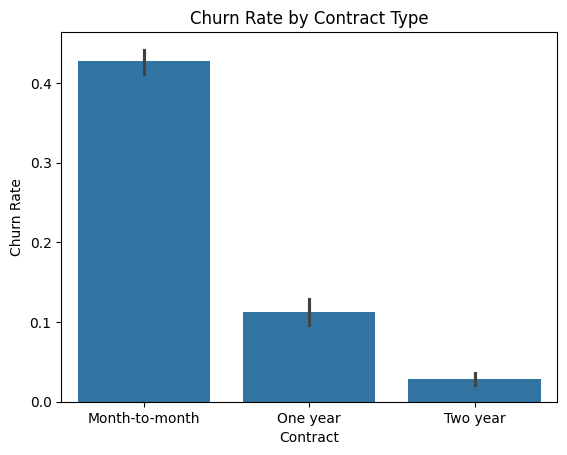

In [44]:
sns.barplot(data=df, x="Contract", y="Churn")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

Month-to-month customers churn at a dramatically higher rate than one- or two-year contract holders. This is likely the single strongest churn signal in the dataset — customers on longer contracts have essentially already committed, while month-to-month customers can leave at any time with no penalty

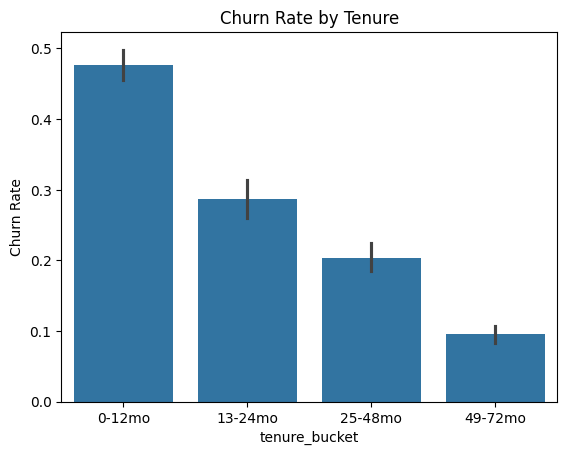

In [45]:
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[0,12,24,48,72], labels=["0-12mo","13-24mo","25-48mo","49-72mo"])
sns.barplot(data=df, x="tenure_bucket", y="Churn")
plt.title("Churn Rate by Tenure")
plt.ylabel("Churn Rate")
plt.show()

Churn is highest among the newest customers (0-12 months) and steadily decreases the longer someone has been a customer.

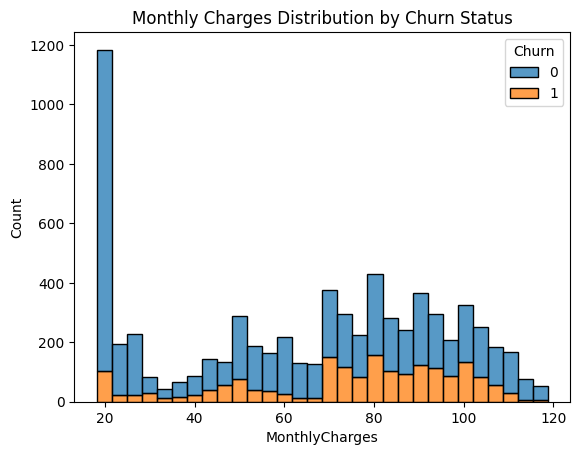

In [46]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", multiple="stack", bins=30)
plt.title("Monthly Charges Distribution by Churn Status")
plt.show()

Customers with higher monthly charges churn more frequently than those with lower bills, suggesting price sensitivity may be a contributing factor to churn alongside contract type and tenure.

In [47]:
df_model = pd.get_dummies(df.drop(columns=["tenure_bucket"]), drop_first=True)
df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


One-hot encoded all categorical variables (contract type, internet service, payment method, etc.), dropping the first category of each to avoid redundancy between columns. df_model is now fully numeric and ready for machine learning.

In [49]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5634
Testing rows: 1409


In [50]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [51]:
y_pred_log = log_model.predict(X_test)

In [52]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

ROC-AUC: 0.8624931423188796


In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [54]:
y_pred_rf = rf_model.predict(X_test)

In [55]:
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409

ROC-AUC: 0.8381949548169387


Comparing both models on ROC-AUC and recall for the churned class:
- Logistic Regression: ROC-AUC 0.862, recall 0.60, precision 0.69
- Random Forest: ROC-AUC 0.838, recall 0.45, precision 0.64

Logistic Regression outperformed Random Forest on every metric here. This is a useful reminder that a simpler, more interpretable model can beat a more complex one — likely because churn drivers in this dataset (contract length, tenure) are fairly linear relationships that Logistic Regression captures well. Moving forward with Logistic Regression as the primary model, since it's both more accurate and easier to explain to business stakeholders.

In [61]:
coefficients = pd.Series(log_model.coef_[0], index=X_train.columns)
coefficients.sort_values(key=abs, ascending=False).head(10)

,0
Contract_Two year,-1.392227
InternetService_Fiber optic,0.639905
Contract_One year,-0.632453
OnlineSecurity_Yes,-0.471021
PhoneService_Yes,-0.450060
TechSupport_Yes,-0.392002
PaperlessBilling_Yes,0.336965
PaymentMethod_Electronic check,0.322967
MultipleLines_No phone service,0.275820
StreamingMovies_Yes,0.220920


In [62]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(log_model, "models/churn_model.pkl")
print("Model saved!")

Model saved!
